# Stage 2: Sleep-Based Threshold Adjustment — Fitbit PMData

This notebook runs Stage 2 of the Hybrid Architecture on Fitbit sleep data from 6 participants.

**Stage 2 Logic:** Compare last night's sleep to a personal rolling average (30 nights), then adjust the stress detection threshold for Stage 3.
- Poor sleep → lower threshold (more sensitive to stress)
- Good sleep → higher threshold (less sensitive)

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stage2_sleep_rules import SleepQualityAssessor
from run_stage2_fitbit import load_fitbit_sleep, run_stage2, PARTICIPANTS

## 1. Run Stage 2 on All Participants

In [2]:
# Run Stage 2 and collect results into a single DataFrame
all_results = []
for pid in PARTICIPANTS:
    results = run_stage2(pid)
    for r in results:
        r['participant'] = pid
    all_results.extend(results)

df = pd.DataFrame(all_results)
df['date'] = pd.to_datetime(df['date'])
print(f"Total nights across all participants: {len(df)}")
df.head(10)

Total nights across all participants: 755


,date,sleep_hours,baseline_hours,sleep_ratio,quality,threshold_multiplier,adjusted_threshold,participant
0,2019-11-07,6.933333,7.000000,0.990476,normal,1.00,60,p04
1,2019-11-08,6.683333,7.000000,0.954762,normal,1.00,60,p04
2,2019-11-09,7.866667,7.000000,1.123810,good,1.05,63,p04
3,2019-11-10,8.683333,7.000000,1.240476,excellent,1.08,64,p04
4,2019-11-11,7.166667,7.000000,1.023810,normal,1.00,60,p04
5,2019-11-12,7.366667,7.000000,1.052381,normal,1.00,60,p04
6,2019-11-13,6.833333,7.000000,0.976190,normal,1.00,60,p04
7,2019-11-14,7.050000,7.361905,0.957633,normal,1.00,60,p04
8,2019-11-15,7.833333,7.322917,1.069701,normal,1.00,60,p04
9,2019-11-16,1.500000,7.379630,0.203262,very_poor,0.80,48,p04


## 2. Per-Participant Summary

In [3]:
summary = df.groupby('participant').agg(
    nights=('sleep_hours', 'count'),
    avg_sleep=('sleep_hours', 'mean'),
    std_sleep=('sleep_hours', 'std'),
    min_sleep=('sleep_hours', 'min'),
    max_sleep=('sleep_hours', 'max'),
    avg_threshold=('adjusted_threshold', 'mean'),
).round(2)

summary

,nights,avg_sleep,std_sleep,min_sleep,max_sleep,avg_threshold
participant,,,,,,
p04,149,7.06,1.53,1.50,10.47,59.10
p08,137,7.35,0.96,3.73,10.35,59.39
p09,141,7.08,1.97,1.77,13.72,57.02
p11,123,7.10,0.89,4.33,9.23,59.11
p13,53,6.80,1.36,0.90,10.30,58.81
p16,152,6.83,1.48,2.15,12.22,58.07


## 3. Sleep Quality Distribution by Participant

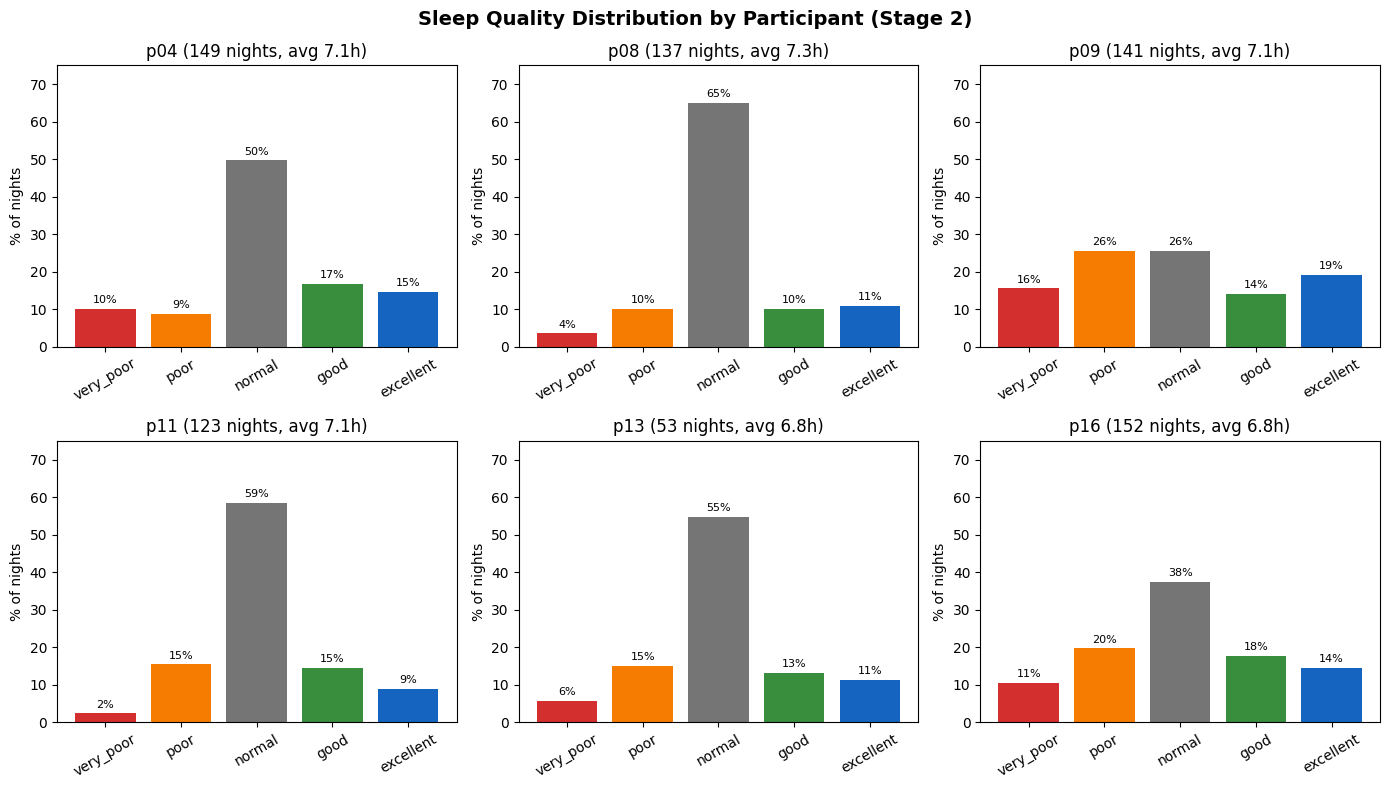

In [4]:
quality_order = ['very_poor', 'poor', 'normal', 'good', 'excellent']
colors = {'very_poor': '#d32f2f', 'poor': '#f57c00', 'normal': '#757575', 'good': '#388e3c', 'excellent': '#1565c0'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, pid in enumerate(PARTICIPANTS):
    pdf = df[df['participant'] == pid]
    counts = pdf['quality'].value_counts()
    counts = counts.reindex(quality_order, fill_value=0)
    pcts = counts / counts.sum() * 100

    bars = axes[i].bar(quality_order, pcts, color=[colors[q] for q in quality_order])
    axes[i].set_title(f"{pid} ({len(pdf)} nights, avg {pdf['sleep_hours'].mean():.1f}h)")
    axes[i].set_ylabel('% of nights')
    axes[i].set_ylim(0, 75)
    axes[i].tick_params(axis='x', rotation=30)

    for bar, pct in zip(bars, pcts):
        if pct > 0:
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        f'{pct:.0f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Sleep Quality Distribution by Participant (Stage 2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Sleep Hours Over Time

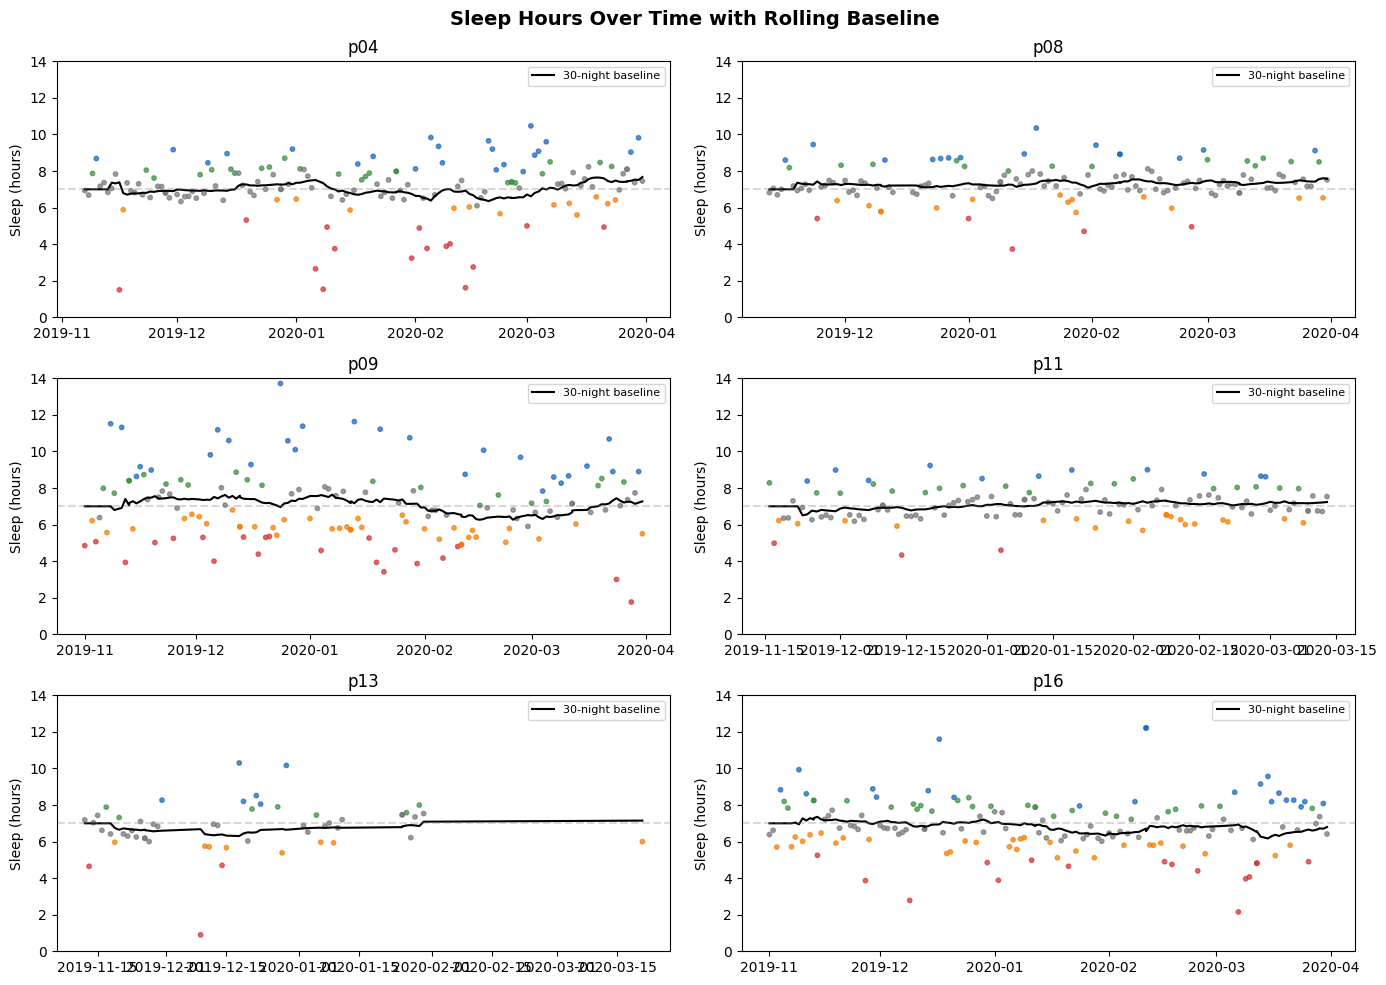

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, pid in enumerate(PARTICIPANTS):
    pdf = df[df['participant'] == pid].sort_values('date')
    
    # Color each point by quality
    point_colors = [colors[q] for q in pdf['quality']]
    axes[i].scatter(pdf['date'], pdf['sleep_hours'], c=point_colors, s=10, alpha=0.7)
    
    # Rolling baseline
    axes[i].plot(pdf['date'], pdf['baseline_hours'], color='black', linewidth=1.5, label='30-night baseline')
    
    axes[i].set_title(f"{pid}")
    axes[i].set_ylabel('Sleep (hours)')
    axes[i].set_ylim(0, 14)
    axes[i].axhline(y=7, color='gray', linestyle='--', alpha=0.3)
    axes[i].legend(fontsize=8)

plt.suptitle('Sleep Hours Over Time with Rolling Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Adjusted Stress Threshold Over Time

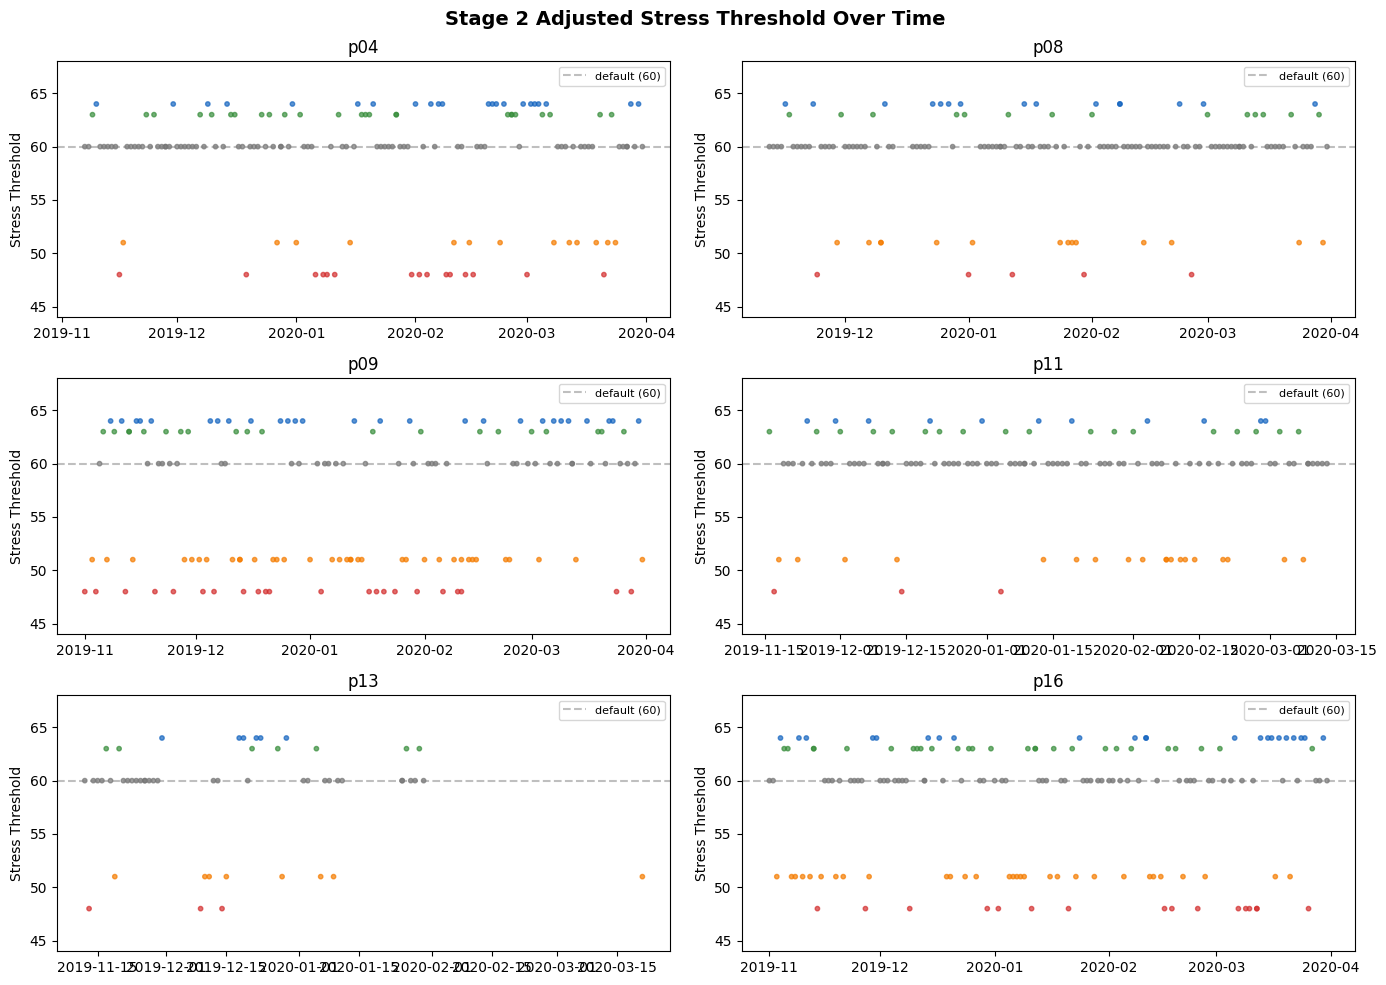

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

threshold_colors = {48: '#d32f2f', 51: '#f57c00', 60: '#757575', 63: '#388e3c', 64: '#1565c0'}

for i, pid in enumerate(PARTICIPANTS):
    pdf = df[df['participant'] == pid].sort_values('date')
    
    point_colors = [threshold_colors.get(t, '#757575') for t in pdf['adjusted_threshold']]
    axes[i].scatter(pdf['date'], pdf['adjusted_threshold'], c=point_colors, s=10, alpha=0.7)
    axes[i].axhline(y=60, color='gray', linestyle='--', alpha=0.5, label='default (60)')
    
    axes[i].set_title(f"{pid}")
    axes[i].set_ylabel('Stress Threshold')
    axes[i].set_ylim(44, 68)
    axes[i].legend(fontsize=8)

plt.suptitle('Stage 2 Adjusted Stress Threshold Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Overall Quality Distribution (All Participants)

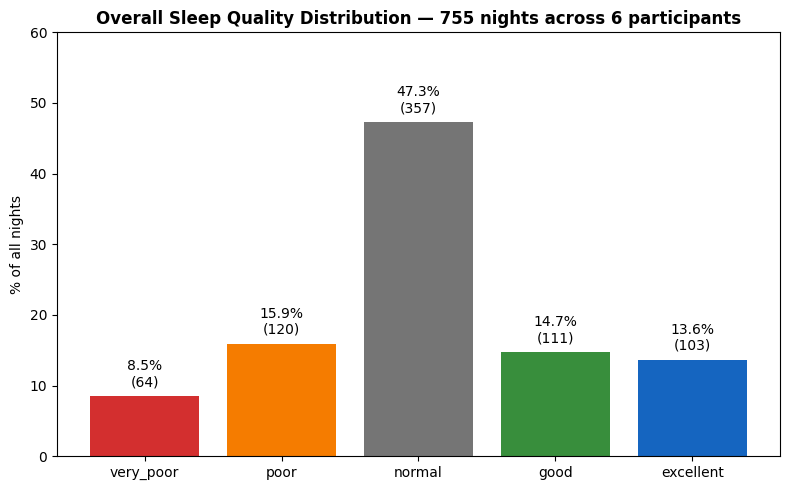

In [7]:
quality_counts = df['quality'].value_counts().reindex(quality_order, fill_value=0)
quality_pcts = quality_counts / quality_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quality_order, quality_pcts, color=[colors[q] for q in quality_order])

for bar, pct, count in zip(bars, quality_pcts, quality_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%\n({count})', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('% of all nights')
ax.set_title(f'Overall Sleep Quality Distribution — {len(df)} nights across {len(PARTICIPANTS)} participants',
             fontweight='bold')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

## 7. Key Takeaways

In [8]:
poor_nights = df[df['quality'].isin(['very_poor', 'poor'])]
good_nights = df[df['quality'].isin(['good', 'excellent'])]

print("Stage 2 Impact Summary")
print("=" * 50)
print(f"Total nights analyzed: {len(df)}")
print(f"")
print(f"Nights with LOWERED threshold (more stress-sensitive):")
print(f"  Poor/Very Poor sleep: {len(poor_nights)} nights ({len(poor_nights)/len(df)*100:.1f}%)")
print(f"  Threshold range: {poor_nights['adjusted_threshold'].min()}-{poor_nights['adjusted_threshold'].max()} (vs default 60)")
print(f"")
print(f"Nights with RAISED threshold (less stress-sensitive):")
print(f"  Good/Excellent sleep: {len(good_nights)} nights ({len(good_nights)/len(df)*100:.1f}%)")
print(f"  Threshold range: {good_nights['adjusted_threshold'].min()}-{good_nights['adjusted_threshold'].max()} (vs default 60)")
print(f"")
print(f"Nights with DEFAULT threshold (no adjustment):")
print(f"  Normal sleep: {len(df) - len(poor_nights) - len(good_nights)} nights ({(len(df) - len(poor_nights) - len(good_nights))/len(df)*100:.1f}%)")

Stage 2 Impact Summary
Total nights analyzed: 755

Nights with LOWERED threshold (more stress-sensitive):
  Poor/Very Poor sleep: 184 nights (24.4%)
  Threshold range: 48-51 (vs default 60)

Nights with RAISED threshold (less stress-sensitive):
  Good/Excellent sleep: 214 nights (28.3%)
  Threshold range: 63-64 (vs default 60)

Nights with DEFAULT threshold (no adjustment):
  Normal sleep: 357 nights (47.3%)
